# Corrlation matrix, gChirp features

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [2]:
df = pd.read_pickle("../datasets/Averages_gChirp_C1C2DETANO.pkl")
df

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,average,average_norm,average_t0,average_dt,triggertimes_rel,qidx,min_qidx
0,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,1,1,"[0.23404275666265387, 0.2381303010000348, 0.24...","[0.13093252217697324, 0.13321925173543125, 0.1...",0.0,0.002,"[0.0, 4.9980016]",0.306987,0.2
1,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,2,1,"[0.8592742807976649, 0.862168467678105, 0.8650...","[0.48455278264264817, 0.48618484162281833, 0.4...",0.0,0.002,"[0.0, 4.9980016]",0.397395,0.2
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,3,1,"[0.9966721981509353, 0.9982692731988386, 0.999...","[0.501599497802753, 0.5024032646214401, 0.5032...",0.0,0.002,"[0.0, 4.9980016]",0.442943,0.2
3,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,4,1,"[-0.11012223462448449, -0.11653696637358568, -...","[-0.06841417883949284, -0.07239937407810096, -...",0.0,0.002,"[0.0, 4.9980016]",0.267124,0.2
4,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,5,1,"[1.0140207452784273, 1.014220858071091, 1.0144...","[0.5124799892216649, 0.5125811250241669, 0.512...",0.0,0.002,"[0.0, 4.9980016]",0.239614,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3779,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,183,1,"[0.8112028982575517, 0.7867748997893866, 0.773...","[0.3587111864995656, 0.34790920794013624, 0.34...",0.0,0.002,"[0.0, 4.9971995]",0.331610,0.2
3780,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,184,1,"[1.2339049363468084, 1.2414545536000525, 1.245...","[0.5019784434913204, 0.5050497863525937, 0.506...",0.0,0.002,"[0.0, 4.9971995]",0.448928,0.2
3781,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,185,1,"[0.1381078234772653, 0.142473841751133, 0.1468...","[0.06722641006479439, 0.069351646184222, 0.071...",0.0,0.002,"[0.0, 4.9971995]",0.294794,0.2
3782,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,186,1,"[0.4181908417071479, 0.4380852987568168, 0.457...","[0.15175416080599652, 0.15897351219575662, 0.1...",0.0,0.002,"[0.0, 4.9971995]",0.336143,0.2


In [3]:
# Determine the set of cond2 values per (date, field) group
group_conditions = df.groupby(["date", "field"])["cond2"].apply(lambda s: set(s.unique()))

# Identify which groups are C1/C2 vs C1/DETANO
c1_c2_groups = group_conditions[group_conditions == {"C1", "C2"}].index
c1_detano_groups = group_conditions[group_conditions == {"C1", "DETANO"}].index

# Build a boolean mask using the (date, field) MultiIndex
df_idx = df.set_index(["date", "field"]).index

df_c1_c2_chirp = df[df_idx.isin(c1_c2_groups)]
df_c1_detano_chirp = df[df_idx.isin(c1_detano_groups)]

print(f"C1/C2 groups: {len(c1_c2_groups)}")
print(f"C1/DETANO groups: {len(c1_detano_groups)}")

C1/C2 groups: 5
C1/DETANO groups: 5


# C1 vs C2

In [4]:
dates = df_c1_c2_chirp["date"].unique()

for date in dates:

    df_date = df_c1_c2_chirp[df_c1_c2_chirp["date"] == date]
    fields = df_date["field"].unique()

    for field in fields:

        df_field = df_date[df_date["field"] == field]
        cond2 = df_field["cond2"].unique()

        print(f"{date}; {field}: {cond2}")
    
    #print(f"{date}: {fields}")

2025-09-08; XY3: ['C1' 'C2']
2025-09-08; XY7: ['C1' 'C2']
2025-10-23; XY7: ['C1' 'C2']
2025-10-23; XY5: ['C1' 'C2']
2025-11-19; XY4: ['C1' 'C2']


In [5]:
df_c1_chirp = df_c1_c2_chirp[df_c1_c2_chirp["cond2"] == "C1"]
df_c2_chirp = df_c1_c2_chirp[df_c1_c2_chirp["cond2"] == "C2"]
print(f"Full df: {len(df_c1_c2_chirp)}, C1 from that: {len(df_c1_chirp)}, C2 from that: {len(df_c2_chirp)}")

Full df: 1858, C1 from that: 929, C2 from that: 929


In [6]:
threshold = 0.35

df_c1_chirp_filtered = df_c1_chirp[df_c1_chirp["qidx"] > threshold]
df_c2_chirp_filtered = df_c2_chirp[df_c2_chirp["qidx"] > threshold]

print(f"C1 unfiltered: {len(df_c1_chirp)}, C1 > 0.35: {len(df_c1_chirp_filtered)}, C2 > 0.35: {len(df_c2_chirp_filtered)}")

C1 unfiltered: 929, C1 > 0.35: 841, C2 > 0.35: 667


In [7]:
key_cols = [
    "experimenter", "date", "exp_num", "raw_id", "field",
    "region", "cond1", "stim_name", "roi_id", "preprocess_id"
]

# suppose df_c1_chirp_filtered is your thresholded subset
df_c2_chirp_matched = df_c2_chirp.merge(
    df_c1_chirp_filtered[key_cols].drop_duplicates(),
    on=key_cols,
    how="inner"
)

print(f"C1 unfiltered: {len(df_c1_chirp)}, C1 > 0.35: {len(df_c1_chirp_filtered)}, C2: {len(df_c2_chirp_matched)}")

C1 unfiltered: 929, C1 > 0.35: 841, C2: 841


In [8]:
df_c2_chirp_matched

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,average,average_norm,average_t0,average_dt,triggertimes_rel,qidx,min_qidx
0,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C2,2,1,"[-0.2501811088849842, -0.2542087317300088, -0....","[-0.12632513930109113, -0.12835882609390128, -...",0.0,0.002,"[0.0, 4.9964]",0.346338,0.2
1,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C2,3,1,"[0.2248236583030943, 0.2246520379159759, 0.224...","[0.1527655614913481, 0.15264894705228332, 0.15...",0.0,0.002,"[0.0, 4.9964]",0.348381,0.2
2,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C2,4,1,"[-0.14074771461071064, -0.14042912405909566, -...","[-0.05920844624750182, -0.0590744245221585, -0...",0.0,0.002,"[0.0, 4.9964]",0.334663,0.2
3,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C2,5,1,"[0.36176648754594803, 0.3561538214559283, 0.35...","[0.20580295545044733, 0.20261000278886102, 0.1...",0.0,0.002,"[0.0, 4.9964]",0.239320,0.2
4,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,C2,6,1,"[-0.4600623437249012, -0.45864698719688757, -0...","[-0.25483121310948564, -0.25404723888091496, -...",0.0,0.002,"[0.0, 4.9964]",0.334579,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,183,1,"[0.8112028982575517, 0.7867748997893866, 0.773...","[0.3587111864995656, 0.34790920794013624, 0.34...",0.0,0.002,"[0.0, 4.9971995]",0.331610,0.2
837,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,184,1,"[1.2339049363468084, 1.2414545536000525, 1.245...","[0.5019784434913204, 0.5050497863525937, 0.506...",0.0,0.002,"[0.0, 4.9971995]",0.448928,0.2
838,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,185,1,"[0.1381078234772653, 0.142473841751133, 0.1468...","[0.06722641006479439, 0.069351646184222, 0.071...",0.0,0.002,"[0.0, 4.9971995]",0.294794,0.2
839,Salomon,2025-11-19,2,1,XY4,RR,t,gChirp,C2,186,1,"[0.4181908417071479, 0.4380852987568168, 0.457...","[0.15175416080599652, 0.15897351219575662, 0.1...",0.0,0.002,"[0.0, 4.9971995]",0.336143,0.2


## Correlations

In [9]:
sf = 500  # sampling frequency (Hz)

features = {
    "on":        [round(sf*2),  round(sf*5)],
    "off":       [round(sf*5),  round(sf*8)],
    "low_freq":  [round(sf*10), round(sf*13)],
    "high_freq": [round(sf*15), round(sf*18)],
    "low_cont":  [round(sf*20), round(sf*23)],
    "high_cont": [round(sf*25), round(sf*28)],
}

trace_col = "average_norm"

In [10]:
roi_id_col = None  # e.g. "roi_id" if you have one; otherwise pairing is by row order

if roi_id_col is not None:
    c1 = df_c1_chirp_filtered.set_index(roi_id_col)
    c2 = df_c2_chirp_matched.set_index(roi_id_col)
    common = c1.index.intersection(c2.index)
    print(f"C1: {len(c1)} ROIs, C2: {len(c2)} ROIs, shared: {len(common)}")
    c1, c2 = c1.loc[common], c2.loc[common]
else:
    assert len(df_c1_chirp_filtered) == len(df_c2_chirp_matched), "Row counts differ!"
    c1 = df_c1_chirp_filtered.reset_index(drop=True)
    c2 = df_c2_chirp_matched.reset_index(drop=True)

print(f"Number of paired ROIs: {len(c1)}")

Number of paired ROIs: 841


In [11]:
max_end = max(end for _, end in features.values())

len_c1 = c1[trace_col].apply(lambda x: len(np.asarray(x)))
len_c2 = c2[trace_col].apply(lambda x: len(np.asarray(x)))

print("C1 trace lengths:", len_c1.unique())
print("C2 trace lengths:", len_c2.unique())
print("Required length (max window end):", max_end)

too_short = (len_c1 < max_end) | (len_c2 < max_end)
print(f"ROIs with traces too short: {too_short.sum()}")

C1 trace lengths: [16516]
C2 trace lengths: [16516]
Required length (max window end): 14000
ROIs with traces too short: 0


In [12]:
def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) != len(b) or len(a) < 2:
        return np.nan
    mask = ~np.isnan(a) & ~np.isnan(b)
    a, b = a[mask], b[mask]
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


def feature_correlations(trace0, trace1, features):
    trace0 = np.asarray(trace0, dtype=float)
    trace1 = np.asarray(trace1, dtype=float)
    return {name: safe_corr(trace0[start:end], trace1[start:end])
            for name, (start, end) in features.items()}

In [13]:
key_cols = ["experimenter", "date", "exp_num", "raw_id", "field",
            "region", "cond1", "stim_name", "roi_id", "preprocess_id"]

# If roi_id was moved into the index in Cell 2, bring it back as a column
c1_k = c1.reset_index() if roi_id_col is not None else c1
c2_k = c2.reset_index() if roi_id_col is not None else c2

missing = [k for k in key_cols if k not in c1_k.columns or k not in c2_k.columns]
assert not missing, f"Missing key columns: {missing}"

# Keys that are identical in both dataframes for every ROI are stored once;
# keys that differ are stored as <key>_c1 and <key>_c2
differing = [k for k in key_cols
             if not (c1_k[k].astype(str).values == c2_k[k].astype(str).values).all()]
shared = [k for k in key_cols if k not in differing]
print("Shared keys:   ", shared)
print("Differing keys:", differing)

results = []
for i in range(len(c1_k)):
    row1 = c1_k.iloc[i]
    row2 = c2_k.iloc[i]

    rec = {k: row1[k] for k in shared}
    for k in differing:
        rec[f"{k}_c1"] = row1[k]
        rec[f"{k}_c2"] = row2[k]

    rec.update(feature_correlations(row1[trace_col], row2[trace_col], features))
    results.append(rec)

index_cols = shared + [f"{k}_{s}" for k in differing for s in ("c1", "c2")]
df_corr = pd.DataFrame(results).set_index(index_cols)
df_corr_flat = df_corr.reset_index()

assert df_corr.index.is_unique, "Primary keys do not uniquely identify ROIs!"
df_corr_flat.head()

Shared keys:    ['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region', 'cond1', 'stim_name', 'roi_id', 'preprocess_id']
Differing keys: []


,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
0,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,2,1,0.024493,0.342368,0.701450,0.156585,0.002597,0.517791
1,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,3,1,0.715125,0.190519,0.724275,0.229853,-0.055882,0.371586
2,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,4,1,0.189879,0.087665,0.760895,0.145030,-0.421719,0.203696
3,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,5,1,0.118643,0.029719,0.435635,0.108422,0.040743,0.257246
4,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,6,1,0.611548,0.643761,0.631565,0.042763,-0.041002,0.586026


In [14]:
df_corr_flat.to_pickle(f"../datasets/gChirp_Correlations_C1C2.pkl")

In [15]:
date = datetime.date(2025, 9, 8)
date_str = date.strftime("%Y%m%d")
field = "XY3"
roi = 5

df_filtered = df_corr_flat[
    (df_corr_flat["date"] == date) &
    (df_corr_flat["field"] == field) &
    (df_corr_flat["roi_id"] == roi)
]

df_filtered

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
3,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,5,1,0.118643,0.029719,0.435635,0.108422,0.040743,0.257246


In [16]:
summary = df_corr.agg(["count", "mean", "median", "std"]).T

z = np.arctanh(df_corr.clip(-0.9999, 0.9999))
summary["fisher_mean_r"] = np.tanh(z.mean())

summary

,count,mean,median,std,fisher_mean_r
on,841.0,0.746943,0.804832,0.190383,0.798750
off,841.0,0.441199,0.487976,0.298921,0.494086
low_freq,841.0,0.503330,0.559571,0.286996,0.563080
high_freq,841.0,0.044888,0.046555,0.246903,0.047774
low_cont,841.0,0.015659,0.015920,0.223884,0.016141
high_cont,841.0,0.250825,0.261295,0.253344,0.269885


/tmp/ipykernel_397737/4233602558.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(features), showfliers=False)


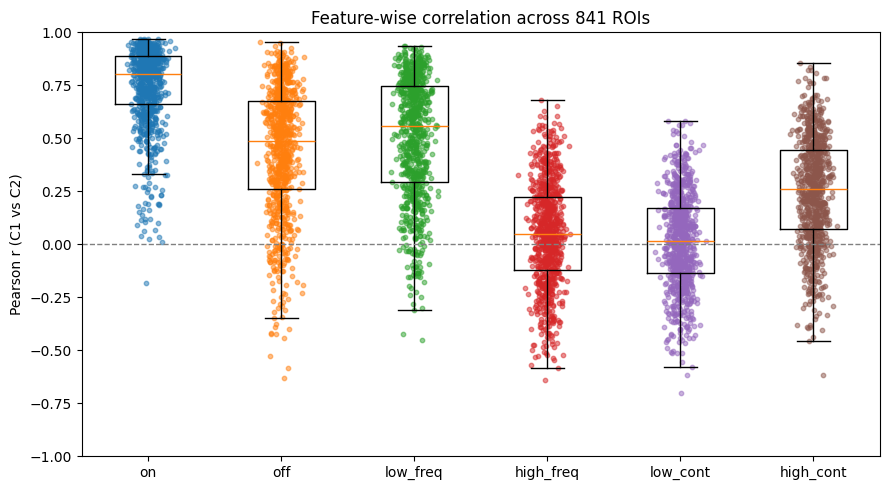

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

data = [df_corr[f].dropna().values for f in features]
ax.boxplot(data, labels=list(features), showfliers=False)

for i, d in enumerate(data, start=1):
    jitter = np.random.normal(0, 0.06, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, s=10, alpha=0.5)

ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_ylabel("Pearson r (C1 vs C2)")
ax.set_title(f"Feature-wise correlation across {len(df_corr)} ROIs")
ax.set_ylim(-1,1)
plt.tight_layout()
plt.savefig(f"../plots/correlation_analysis/gChirp_C1C2.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Heatmap Correlations

In [18]:
#df_chirp = df_filtered[df_filtered["stim_name"] == "gChirp"]

# Determine target length (max across all rows)
max_length = df_c1_chirp_filtered["average_norm"].apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# def pad_to_length(arr, target_length, pad_value=np.nan):
#     arr = np.asarray(arr)
#     pad_width = target_length - arr.shape[0]
#     if pad_width < 0:
#         raise ValueError(f"Array longer than target length: {arr.shape[0]} > {target_length}")
#     return np.pad(arr, (0, pad_width), mode="constant", constant_values=pad_value)

def pad_to_length(arr, target_length):
    arr = np.asarray(arr)
    
    pad_width = target_length - arr.shape[0]
    
    if pad_width < 0:
        raise ValueError(
            f"Array longer than target length: "
            f"{arr.shape[0]} > {target_length}"
        )
    
    # Mean of the last second (500 samples at 500 Hz)
    pad_value = np.mean(arr[-500:])
    
    return np.pad(
        arr,
        (0, pad_width),
        mode="constant",
        constant_values=pad_value
    )

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_chirp_filtered["average_norm"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_chirp_c1 = np.stack(padded_traces.values)
average_traces_chirp_c1.shape

Padding all arrays to length: 16516


(841, 16516)

In [19]:
fps = 500  # frames per second, same as used later for the scale bar

start_time = 3.0  # seconds, start of on-step

def get_onstep_mean(row):
    trigs = np.asarray(row["triggertimes_rel"])
    end_time = trigs[1]  # second trigger = end of on-step (~4.9972s)
    
    trace = np.asarray(row["average_norm"])
    start_frame = int(round(start_time * fps))
    end_frame = int(round(end_time * fps))
    
    window = trace[start_frame:end_frame]
    return np.nanmean(window)

# Compute mean response in the on-step window for every ROI
onstep_means = df_c1_chirp_filtered.apply(get_onstep_mean, axis=1).values

# Sort descending (max -> min). NaNs (if any) get pushed to the bottom.
means_filled = np.where(np.isnan(onstep_means), -np.inf, onstep_means)
sort_idx = np.argsort(-means_filled)

# Apply the sort to the traces used for the heatmap
correlation_values = df_corr.values[sort_idx]

print("Sorted", len(sort_idx), "ROIs by on-step mean (max to min).")

Sorted 841 ROIs by on-step mean (max to min).


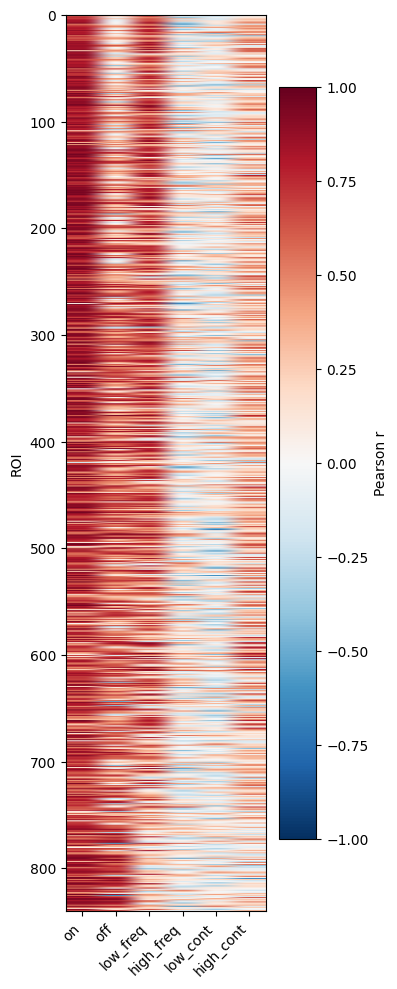

In [20]:
fig, ax = plt.subplots(figsize=(4, 10))
im = ax.imshow(correlation_values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
#im = ax.imshow(df_corr.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_xticklabels(list(features), rotation=45, ha="right")
ax.set_ylabel("ROI")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.savefig(f"../plots/correlation_analysis/gChirp_C1C2_CorrHeatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Deltas

In [21]:
def safe_delta(a,b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) != len(b) or len(a) < 2:
        return np.nan

    mask = ~np.isnan(a) & ~np.isnan(b)
    a, b = a[mask], b[mask]
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    diff = np.mean(b) - np.mean(a)
    
    return diff

def feature_deltas(trace0, trace1, features):

    trace0 = np.asarray(trace0, dtype=float)
    trace1 = np.asarray(trace1, dtype=float)
    return {name: safe_delta(trace0[start:end], trace1[start:end])
            for name, (start, end) in features.items()}

In [22]:
key_cols = ["experimenter", "date", "exp_num", "raw_id", "field",
            "region", "cond1", "stim_name", "roi_id", "preprocess_id"]

# If roi_id was moved into the index in Cell 2, bring it back as a column
c1_k = c1.reset_index() if roi_id_col is not None else c1
c2_k = c2.reset_index() if roi_id_col is not None else c2

missing = [k for k in key_cols if k not in c1_k.columns or k not in c2_k.columns]
assert not missing, f"Missing key columns: {missing}"

# Keys that are identical in both dataframes for every ROI are stored once;
# keys that differ are stored as <key>_c1 and <key>_c2
differing = [k for k in key_cols
             if not (c1_k[k].astype(str).values == c2_k[k].astype(str).values).all()]
shared = [k for k in key_cols if k not in differing]
print("Shared keys:   ", shared)
print("Differing keys:", differing)

results = []
for i in range(len(c1_k)):
    row1 = c1_k.iloc[i]
    row2 = c2_k.iloc[i]

    rec = {k: row1[k] for k in shared}
    for k in differing:
        rec[f"{k}_c1"] = row1[k]
        rec[f"{k}_c2"] = row2[k]

    rec.update(feature_deltas(row1[trace_col], row2[trace_col], features))
    results.append(rec)

index_cols = shared + [f"{k}_{s}" for k in differing for s in ("c1", "c2")]
df_delta = pd.DataFrame(results).set_index(index_cols)
df_delta_flat = df_corr.reset_index()

assert df_corr.index.is_unique, "Primary keys do not uniquely identify ROIs!"
df_delta_flat.head()

Shared keys:    ['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region', 'cond1', 'stim_name', 'roi_id', 'preprocess_id']
Differing keys: []


,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
0,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,2,1,0.024493,0.342368,0.701450,0.156585,0.002597,0.517791
1,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,3,1,0.715125,0.190519,0.724275,0.229853,-0.055882,0.371586
2,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,4,1,0.189879,0.087665,0.760895,0.145030,-0.421719,0.203696
3,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,5,1,0.118643,0.029719,0.435635,0.108422,0.040743,0.257246
4,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,6,1,0.611548,0.643761,0.631565,0.042763,-0.041002,0.586026


In [23]:
df_delta_flat.to_pickle(f"../datasets/Deltas_gChirp_C1C2.pkl")

In [24]:
df_filtered = df_delta_flat[
    (df_delta_flat["date"] == date) &
    (df_delta_flat["field"] == field) &
    (df_delta_flat["roi_id"] == roi)
]

df_filtered

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
3,Salomon,2025-09-08,2,1,XY3,RR,t,gChirp,5,1,0.118643,0.029719,0.435635,0.108422,0.040743,0.257246


In [25]:
summary = df_delta.agg(["count", "mean", "median", "std"]).T

z = np.arctanh(df_corr.clip(-0.9999, 0.9999))
summary["fisher_mean_delta"] = np.tanh(z.mean())

summary

,count,mean,median,std,fisher_mean_delta
on,841.0,0.068376,0.056111,0.287938,0.798750
off,841.0,0.007955,0.008364,0.238344,0.494086
low_freq,841.0,0.034836,-0.007242,0.259293,0.563080
high_freq,841.0,-0.005213,-0.039696,0.306694,0.047774
low_cont,841.0,0.128671,0.078581,0.286476,0.016141
high_cont,841.0,0.003921,-0.020455,0.250317,0.269885


/tmp/ipykernel_397737/3977338583.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(features), showfliers=False)


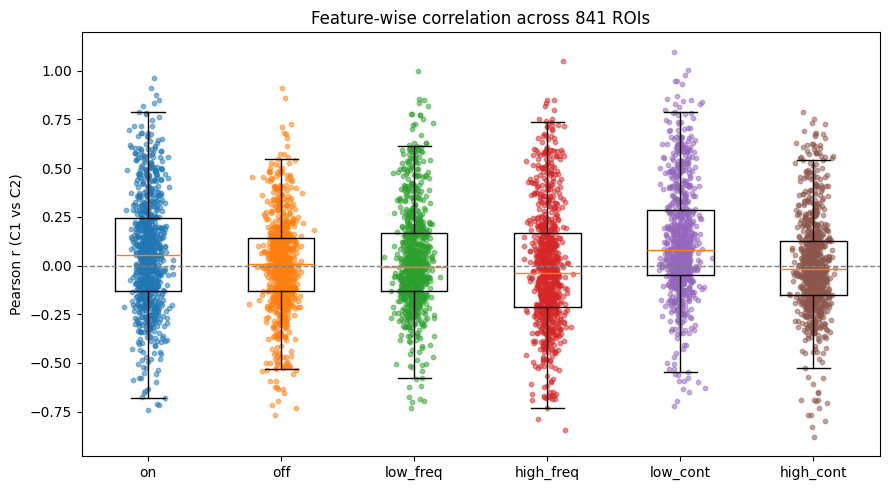

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

data = [df_delta[f].dropna().values for f in features]
ax.boxplot(data, labels=list(features), showfliers=False)

for i, d in enumerate(data, start=1):
    jitter = np.random.normal(0, 0.06, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, s=10, alpha=0.5)

ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_ylabel("Pearson r (C1 vs C2)")
ax.set_title(f"Feature-wise correlation across {len(df_corr)} ROIs")
#ax.set_ylim(-1,1)
plt.tight_layout()
plt.savefig(f"../plots/correlation_analysis/gChirp_C1C2_delta.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# C1 vs DETANO

In [27]:
df_c1_detano_chirp

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,preprocess_id,average,average_norm,average_t0,average_dt,triggertimes_rel,qidx,min_qidx
0,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,1,1,"[0.23404275666265387, 0.2381303010000348, 0.24...","[0.13093252217697324, 0.13321925173543125, 0.1...",0.0,0.002,"[0.0, 4.9980016]",0.306987,0.2
1,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,2,1,"[0.8592742807976649, 0.862168467678105, 0.8650...","[0.48455278264264817, 0.48618484162281833, 0.4...",0.0,0.002,"[0.0, 4.9980016]",0.397395,0.2
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,3,1,"[0.9966721981509353, 0.9982692731988386, 0.999...","[0.501599497802753, 0.5024032646214401, 0.5032...",0.0,0.002,"[0.0, 4.9980016]",0.442943,0.2
3,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,4,1,"[-0.11012223462448449, -0.11653696637358568, -...","[-0.06841417883949284, -0.07239937407810096, -...",0.0,0.002,"[0.0, 4.9980016]",0.267124,0.2
4,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,5,1,"[1.0140207452784273, 1.014220858071091, 1.0144...","[0.5124799892216649, 0.5125811250241669, 0.512...",0.0,0.002,"[0.0, 4.9980016]",0.239614,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3405,Salomon,2025-10-23,2,1,XY6,RR,n,gChirp,DETANO,162,1,"[1.5469229581517274, 1.5580796032895443, 1.569...","[0.3813959829548394, 0.38414666915830753, 0.38...",0.0,0.002,"[0.0, 4.994399]",0.511856,0.2
3406,Salomon,2025-10-23,2,1,XY6,RR,n,gChirp,DETANO,163,1,"[-0.28136214900966455, -0.2859424123374712, -0...","[-0.17156898121040404, -0.17436193369386038, -...",0.0,0.002,"[0.0, 4.994399]",0.293715,0.2
3407,Salomon,2025-10-23,2,1,XY6,RR,n,gChirp,DETANO,164,1,"[0.1935724932711898, 0.1924391457822508, 0.191...","[0.09857955302315993, 0.09800237965006603, 0.0...",0.0,0.002,"[0.0, 4.994399]",0.222807,0.2
3408,Salomon,2025-10-23,2,1,XY6,RR,n,gChirp,DETANO,165,1,"[0.36932191803166176, 0.36368663403950235, 0.3...","[0.15628105525454583, 0.1538964469062316, 0.15...",0.0,0.002,"[0.0, 4.994399]",0.284590,0.2


In [28]:
dates = df_c1_detano_chirp["date"].unique()

for date in dates:

    df_date = df_c1_detano_chirp[df_c1_detano_chirp["date"] == date]
    fields = df_date["field"].unique()

    for field in fields:

        df_field = df_date[df_date["field"] == field]
        cond2 = df_field["cond2"].unique()

        print(f"{date}; {field}: {cond2}")
    
    #print(f"{date}: {fields}")

2025-09-08; XY2: ['C1' 'DETANO']
2025-09-08; XY8: ['C1' 'DETANO']
2025-10-23; XY2: ['C1' 'DETANO']
2025-10-23; XY4: ['C1' 'DETANO']
2025-10-23; XY6: ['C1' 'DETANO']


In [29]:
df_c1_chirp = df_c1_detano_chirp[df_c1_detano_chirp["cond2"] == "C1"]
df_no_chirp = df_c1_detano_chirp[df_c1_detano_chirp["cond2"] == "DETANO"]

print(f"Full df: {len(df_c1_detano_chirp)}")
print(f"C1 from that: {len(df_c1_chirp)}")
print(f"NO from that: {len(df_no_chirp)}")

Full df: 1926
C1 from that: 963
NO from that: 963


In [30]:
threshold = 0.35

df_c1_chirp_filtered = df_c1_chirp[df_c1_chirp["qidx"] > threshold]
df_no_chirp_filtered = df_no_chirp[df_no_chirp["qidx"] > threshold]

print(f"C1 unfiltered: {len(df_c1_chirp)}")
print(f"C1 > 0.35: {len(df_c1_chirp_filtered)}")
print(f"NO > 0.35: {len(df_no_chirp_filtered)}")

C1 unfiltered: 963
C1 > 0.35: 696
NO > 0.35: 511


In [31]:
key_cols = [
    "experimenter", "date", "exp_num", "raw_id", "field",
    "region", "cond1", "stim_name", "roi_id", "preprocess_id"
]

# suppose df_c1_chirp_filtered is your thresholded subset
df_no_chirp_matched = df_no_chirp.merge(
    df_c1_chirp_filtered[key_cols].drop_duplicates(),
    on=key_cols,
    how="inner"
)

In [32]:
print(f"C1 unfiltered: {len(df_c1_chirp)}, C1 > 0.35: {len(df_c1_chirp_filtered)}, DETANO: {len(df_no_chirp_matched)}")

C1 unfiltered: 963, C1 > 0.35: 696, DETANO: 696


## Correlations

In [33]:
sf = 500  # sampling frequency (Hz)

features = {
    "on":        [round(sf*2),  round(sf*5)],
    "off":       [round(sf*5),  round(sf*8)],
    "low_freq":  [round(sf*10), round(sf*13)],
    "high_freq": [round(sf*15), round(sf*18)],
    "low_cont":  [round(sf*20), round(sf*23)],
    "high_cont": [round(sf*25), round(sf*28)],
}

trace_col = "average_norm"

In [34]:
roi_id_col = None  # e.g. "roi_id" if you have one; otherwise pairing is by row order

if roi_id_col is not None:
    c1 = df_c1_chirp_filtered.set_index(roi_id_col)
    no = df_no_chirp_matched.set_index(roi_id_col)
    common = c1.index.intersection(no.index)
    print(f"C1: {len(c1)} ROIs, NO: {len(no)} ROIs, shared: {len(common)}")
    c1, no = c1.loc[common], no.loc[common]
else:
    assert len(df_c1_chirp_filtered) == len(df_no_chirp_matched), "Row counts differ!"
    c1 = df_c1_chirp_filtered.reset_index(drop=True)
    no = df_no_chirp_matched.reset_index(drop=True)

print(f"Number of paired ROIs: {len(c1)}")

Number of paired ROIs: 696


In [35]:
max_end = max(end for _, end in features.values())

len_c1 = c1[trace_col].apply(lambda x: len(np.asarray(x)))
len_no = no[trace_col].apply(lambda x: len(np.asarray(x)))

print("C1 trace lengths:", len_c1.unique())
print("NO trace lengths:", len_no.unique())
print("Required length (max window end):", max_end)

too_short = (len_c1 < max_end) | (len_no < max_end)
print(f"ROIs with traces too short: {too_short.sum()}")

C1 trace lengths: [16516]
NO trace lengths: [16515 16516]
Required length (max window end): 14000
ROIs with traces too short: 0


In [36]:
key_cols = ["experimenter", "date", "exp_num", "raw_id", "field",
            "region", "cond1", "stim_name", "roi_id", "preprocess_id"]

# If roi_id was moved into the index in Cell 2, bring it back as a column
c1_k = c1.reset_index() if roi_id_col is not None else c1
no_k = no.reset_index() if roi_id_col is not None else no

missing = [k for k in key_cols if k not in c1_k.columns or k not in no_k.columns]
assert not missing, f"Missing key columns: {missing}"

# Keys that are identical in both dataframes for every ROI are stored once;
# keys that differ are stored as <key>_c1 and <key>_c2
differing = [k for k in key_cols
             if not (c1_k[k].astype(str).values == no_k[k].astype(str).values).all()]
shared = [k for k in key_cols if k not in differing]
print("Shared keys:   ", shared)
print("Differing keys:", differing)

results = []
for i in range(len(c1_k)):
    row1 = c1_k.iloc[i]
    row2 = no_k.iloc[i]

    rec = {k: row1[k] for k in shared}
    for k in differing:
        rec[f"{k}_c1"] = row1[k]
        rec[f"{k}_no"] = row2[k]

    rec.update(feature_correlations(row1[trace_col], row2[trace_col], features))
    results.append(rec)

index_cols = shared + [f"{k}_{s}" for k in differing for s in ("c1", "no")]
df_corr = pd.DataFrame(results).set_index(index_cols)
df_corr_flat = df_corr.reset_index()

assert df_corr.index.is_unique, "Primary keys do not uniquely identify ROIs!"
df_corr_flat.head()

Shared keys:    ['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region', 'cond1', 'stim_name', 'roi_id', 'preprocess_id']
Differing keys: []


,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
0,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,2,1,-0.032612,-0.129869,0.552247,0.447408,-0.180398,-0.121328
1,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,3,1,0.445721,0.142831,0.596516,-0.200003,0.360728,-0.153111
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,7,1,0.546856,-0.158199,0.511532,-0.255671,0.471986,0.499661
3,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,8,1,0.307346,-0.056206,0.640767,-0.240103,0.080912,-0.010071
4,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,11,1,-0.123097,-0.171476,-0.003686,-0.083355,-0.232957,0.182645


In [37]:
df_corr_flat.to_pickle(f"../datasets/gChirp_Correlations_C1DETANO.pkl")

In [38]:
date = datetime.date(2025, 9, 8)
date_str = date.strftime("%Y%m%d")
field = "XY2"
roi = 7

df_filtered = df_corr_flat[
    (df_corr_flat["date"] == date) &
    (df_corr_flat["field"] == field) &
    (df_corr_flat["roi_id"] == roi)
]

df_filtered

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,7,1,0.546856,-0.158199,0.511532,-0.255671,0.471986,0.499661


In [39]:
summary = df_corr.agg(["count", "mean", "median", "std"]).T

z = np.arctanh(df_corr.clip(-0.9999, 0.9999))
summary["fisher_mean_r"] = np.tanh(z.mean())

summary

,count,mean,median,std,fisher_mean_r
on,696.0,0.748754,0.854587,0.255882,0.821965
off,696.0,0.404398,0.359474,0.397298,0.558957
low_freq,696.0,0.515877,0.552510,0.339463,0.627911
high_freq,696.0,0.025899,0.020686,0.233291,0.027412
low_cont,696.0,0.133311,0.096577,0.320911,0.160084
high_cont,696.0,0.268834,0.261252,0.309127,0.308313


/tmp/ipykernel_397737/3117507263.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(features), showfliers=False)


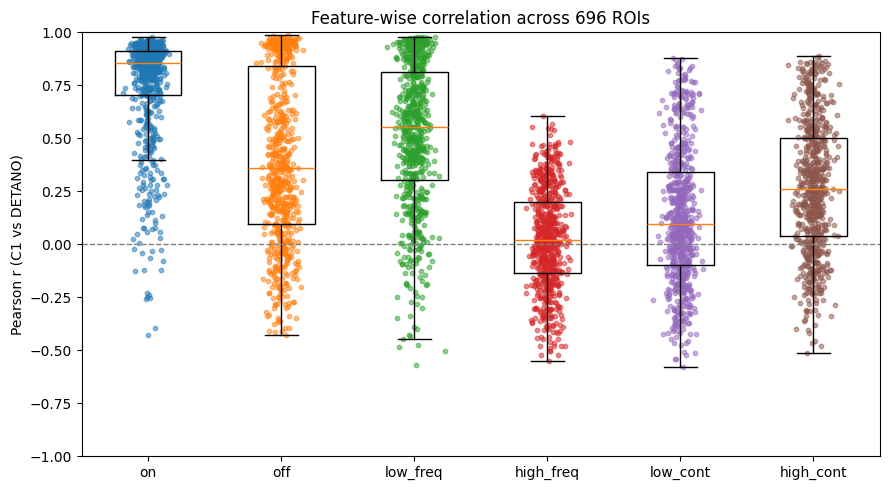

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))

data = [df_corr[f].dropna().values for f in features]
ax.boxplot(data, labels=list(features), showfliers=False)

for i, d in enumerate(data, start=1):
    jitter = np.random.normal(0, 0.06, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, s=10, alpha=0.5)

ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_ylabel("Pearson r (C1 vs DETANO)")
ax.set_title(f"Feature-wise correlation across {len(df_corr)} ROIs")
ax.set_ylim(-1,1)
plt.tight_layout()
plt.savefig(f"../plots/correlation_analysis/gChirp_C1DETANO_Correlations.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Heatmaps

In [41]:
#df_chirp = df_filtered[df_filtered["stim_name"] == "gChirp"]

# Determine target length (max across all rows)
max_length = df_c1_chirp_filtered["average_norm"].apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# def pad_to_length(arr, target_length, pad_value=np.nan):
#     arr = np.asarray(arr)
#     pad_width = target_length - arr.shape[0]
#     if pad_width < 0:
#         raise ValueError(f"Array longer than target length: {arr.shape[0]} > {target_length}")
#     return np.pad(arr, (0, pad_width), mode="constant", constant_values=pad_value)

def pad_to_length(arr, target_length):
    arr = np.asarray(arr)
    
    pad_width = target_length - arr.shape[0]
    
    if pad_width < 0:
        raise ValueError(
            f"Array longer than target length: "
            f"{arr.shape[0]} > {target_length}"
        )
    
    # Mean of the last second (500 samples at 500 Hz)
    pad_value = np.mean(arr[-500:])
    
    return np.pad(
        arr,
        (0, pad_width),
        mode="constant",
        constant_values=pad_value
    )

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_chirp_filtered["average_norm"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_chirp_c1 = np.stack(padded_traces.values)
average_traces_chirp_c1.shape

Padding all arrays to length: 16516


(696, 16516)

In [42]:
fps = 500  # frames per second, same as used later for the scale bar

start_time = 3.0  # seconds, start of on-step

def get_onstep_mean(row):
    trigs = np.asarray(row["triggertimes_rel"])
    end_time = trigs[1]  # second trigger = end of on-step (~4.9972s)
    
    trace = np.asarray(row["average_norm"])
    start_frame = int(round(start_time * fps))
    end_frame = int(round(end_time * fps))
    
    window = trace[start_frame:end_frame]
    return np.nanmean(window)

# Compute mean response in the on-step window for every ROI
onstep_means = df_c1_chirp_filtered.apply(get_onstep_mean, axis=1).values

# Sort descending (max -> min). NaNs (if any) get pushed to the bottom.
means_filled = np.where(np.isnan(onstep_means), -np.inf, onstep_means)
sort_idx = np.argsort(-means_filled)

# Apply the sort to the traces used for the heatmap
correlation_values = df_corr.values[sort_idx]

print("Sorted", len(sort_idx), "ROIs by on-step mean (max to min).")

Sorted 696 ROIs by on-step mean (max to min).


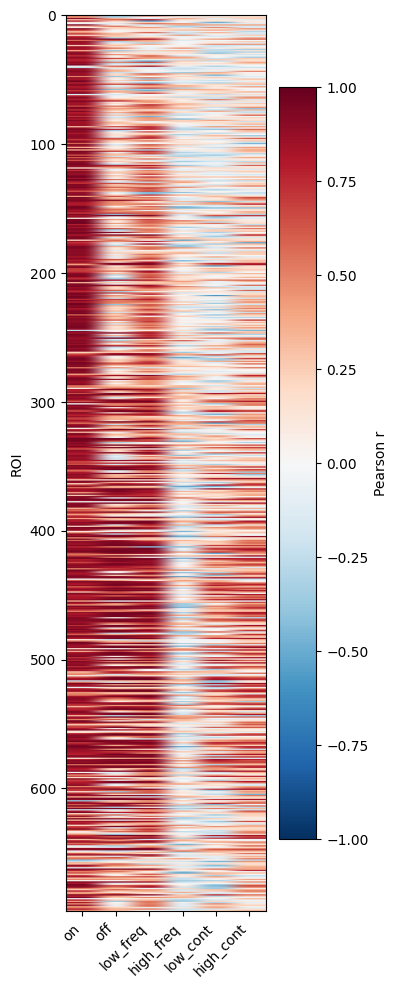

In [43]:
fig, ax = plt.subplots(figsize=(4, 10))
im = ax.imshow(correlation_values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
#im = ax.imshow(df_corr.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_xticklabels(list(features), rotation=45, ha="right")
ax.set_ylabel("ROI")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.savefig(f"../plots/correlation_analysis/gChirp_C1DETANO_CorrHeatmap.png")

plt.show()

## Deltas

In [44]:
key_cols = ["experimenter", "date", "exp_num", "raw_id", "field",
            "region", "cond1", "stim_name", "roi_id", "preprocess_id"]

# If roi_id was moved into the index in Cell 2, bring it back as a column
c1_k = c1.reset_index() if roi_id_col is not None else c1
no_k = no.reset_index() if roi_id_col is not None else no

missing = [k for k in key_cols if k not in c1_k.columns or k not in no_k.columns]
assert not missing, f"Missing key columns: {missing}"

# Keys that are identical in both dataframes for every ROI are stored once;
# keys that differ are stored as <key>_c1 and <key>_no
differing = [k for k in key_cols
             if not (c1_k[k].astype(str).values == no_k[k].astype(str).values).all()]
shared = [k for k in key_cols if k not in differing]
print("Shared keys:   ", shared)
print("Differing keys:", differing)

results = []
for i in range(len(c1_k)):
    row1 = c1_k.iloc[i]
    row2 = no_k.iloc[i]

    rec = {k: row1[k] for k in shared}
    for k in differing:
        rec[f"{k}_c1"] = row1[k]
        rec[f"{k}_no"] = row2[k]

    rec.update(feature_deltas(row1[trace_col], row2[trace_col], features))
    results.append(rec)

index_cols = shared + [f"{k}_{s}" for k in differing for s in ("c1", "no")]
df_delta = pd.DataFrame(results).set_index(index_cols)
df_delta_flat = df_corr.reset_index()

assert df_corr.index.is_unique, "Primary keys do not uniquely identify ROIs!"
df_delta_flat.head()

Shared keys:    ['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region', 'cond1', 'stim_name', 'roi_id', 'preprocess_id']
Differing keys: []


,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
0,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,2,1,-0.032612,-0.129869,0.552247,0.447408,-0.180398,-0.121328
1,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,3,1,0.445721,0.142831,0.596516,-0.200003,0.360728,-0.153111
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,7,1,0.546856,-0.158199,0.511532,-0.255671,0.471986,0.499661
3,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,8,1,0.307346,-0.056206,0.640767,-0.240103,0.080912,-0.010071
4,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,11,1,-0.123097,-0.171476,-0.003686,-0.083355,-0.232957,0.182645


In [45]:
df_delta_flat.to_pickle(f"../datasets/Deltas_gChirp_C1DETANO.pkl")

In [46]:
df_filtered = df_delta_flat[
    (df_delta_flat["date"] == date) &
    (df_delta_flat["field"] == field) &
    (df_delta_flat["roi_id"] == roi)
]

df_filtered

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,roi_id,preprocess_id,on,off,low_freq,high_freq,low_cont,high_cont
2,Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,7,1,0.546856,-0.158199,0.511532,-0.255671,0.471986,0.499661


In [47]:
summary = df_delta.agg(["count", "mean", "median", "std"]).T

z = np.arctanh(df_corr.clip(-0.9999, 0.9999))
summary["fisher_mean_delta"] = np.tanh(z.mean())

summary

,count,mean,median,std,fisher_mean_delta
on,696.0,0.054489,0.044451,0.211689,0.821965
off,696.0,0.007594,-0.031549,0.231183,0.558957
low_freq,696.0,0.001688,-0.001889,0.209492,0.627911
high_freq,696.0,0.003491,-0.032787,0.236452,0.027412
low_cont,696.0,0.088113,0.066117,0.193034,0.160084
high_cont,696.0,0.024448,0.018136,0.177491,0.308313


/tmp/ipykernel_397737/2931974162.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(features), showfliers=False)


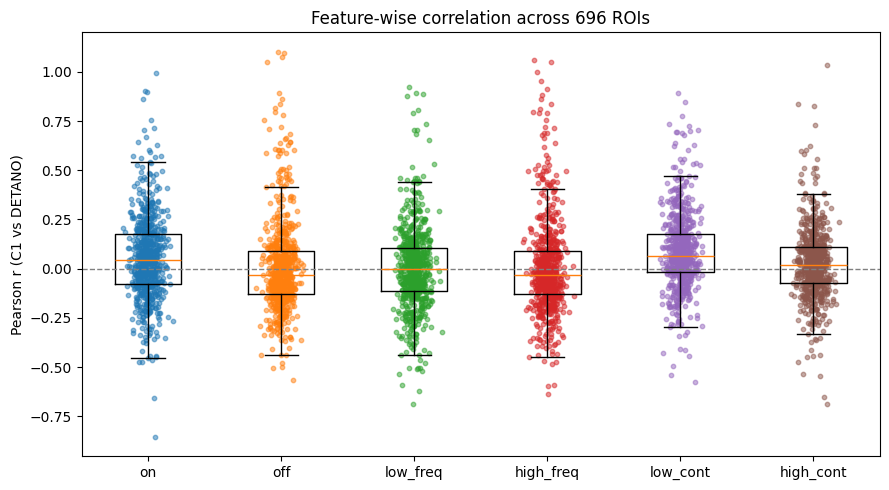

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))

data = [df_delta[f].dropna().values for f in features]
ax.boxplot(data, labels=list(features), showfliers=False)

for i, d in enumerate(data, start=1):
    jitter = np.random.normal(0, 0.06, size=len(d))
    ax.scatter(np.full(len(d), i) + jitter, d, s=10, alpha=0.5)

ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_ylabel("Pearson r (C1 vs DETANO)")
ax.set_title(f"Feature-wise correlation across {len(df_corr)} ROIs")
#ax.set_ylim(-1,1)
plt.tight_layout()
plt.savefig(f"../plots/correlation_analysis/gChirp_C1DETANO_delta.png",
            dpi=300,
            bbox_inches="tight")

plt.show()